# Stock Price Prediction with Machine Learning
## **Single Stock**

## Objective
Train a machine learning model to predict Apple's stock price using historical data and technical indicators.

## Approach
This project applies **linear regression** to time-series data, using lagged closing prices and common technical indicators (Simple Moving Averages and RSI). The model is evaluated on a train/test split and extended to generate short-term forecasts. Both static (frozen indicators) and dynamic (rolling updates of SMA/RSI) forecasts are compared to illustrate the trade-off between in-sample accuracy and out-of-sample realism.

## Key Features
- Historical data downloaded via `yfinance`
- Lag features (1, 2, 3, 5, 10 days)
- Technical indicators (SMA-5, SMA-10, RSI-14)
- Train/test evaluation with RMSE, MAE, R²
- Forecast visualization (static vs dynamic)

## Project Structure
For clarity and ease of understanding, this project is organized into two separate Colab notebooks:
- **Single Equity (Apple):** Focuses on one stock, demonstrating lag features, SMA, RSI, and the comparison between static and dynamic forecasts.
- **Portfolio Forecasting:** Extends the same methodology to multiple equities, highlighting how regression models can be scaled to a portfolio context and used for comparative analysis.

Both notebooks are included in this repository to provide a step-by-step learning path: starting with a single equity model and then expanding to a multi-asset framework.

---



## Part 1: Static Forecast

In this section, we train a linear regression model using lagged closing prices and technical indicators (SMA and RSI). The indicators are **frozen at their last observed values**, meaning they do not update during the forecast horizon. This produces a **static forecast** for the next 7 days.

### Key Points
- Historical fit is shown for the last 60 days.
- Forecast is generated using lag features and fixed SMA/RSI values.
- The static forecast often exhibits **volatility** because indicators are not recalculated.
- Metrics (RMSE, MAE, R²) are evaluated on the test set to demonstrate in-sample accuracy.


[*********************100%***********************]  1 of 1 completed



## Model Performance on Test Set

|                                |   Value |
|--------------------------------|---------|
| RMSE (Root Mean Squared Error) |  2.05   |
| MAE (Mean Absolute Error)      |  1.45   |
| R² Score (Explained Variance)  |  0.9955 |

## Current Closing Price

| Date       |   Price (USD) |
|------------|---------------|
| 2026-03-10 |        260.83 |

## Predicted Closing Prices (from latest available date)

| Day   |   Price (USD) |
|-------|---------------|
| Day 1 |        261.06 |
| Day 2 |        303.9  |
| Day 3 |        260.13 |
| Day 4 |        234.54 |
| Day 5 |        220.56 |
| Day 6 |        278.05 |
| Day 7 |        310.56 |


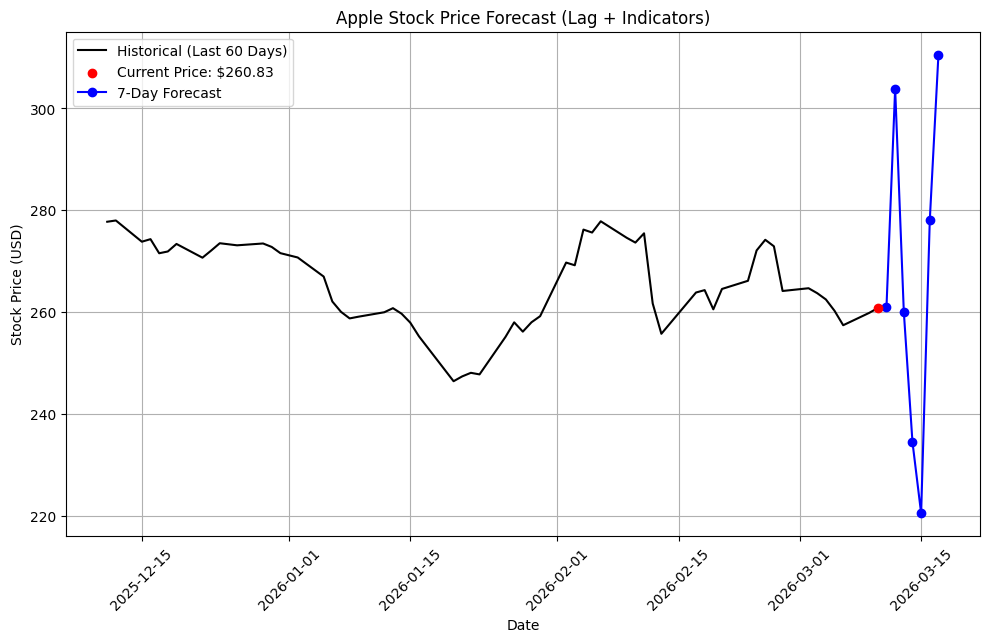

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates
from tabulate import tabulate

# Step 1: Download historical stock data for Apple up to today's date
today = datetime.today().strftime('%Y-%m-%d')
df = yf.download('AAPL', start='2015-01-01', end=today, auto_adjust=True)

# Step 2: Prepare lag features
df['Lag1'] = df['Close'].shift(1)
df['Lag2'] = df['Close'].shift(2)
df['Lag3'] = df['Close'].shift(3)
df['Lag5'] = df['Close'].shift(5)
df['Lag10'] = df['Close'].shift(10)

# Step 3: Add Technical Indicators (SMA and RSI)
df['SMA_5'] = df['Close'].rolling(window=5).mean()
df['SMA_10'] = df['Close'].rolling(window=10).mean()

delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# Step 4: Drop rows with NaN values created by rolling calculations
df.dropna(inplace=True)

# Step 5: Define features and target (which includes indicators)
X = df[['Lag1', 'Lag2', 'Lag3', 'Lag5', 'Lag10', 'SMA_5', 'SMA_10', 'RSI_14']]
y = df['Close']

# Step 6: Train-test split (no shuffle to preserve time order)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 7: Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 8: Predict on test set
y_pred = model.predict(X_test)

# Step 9: Performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Use DataFrame + tabulate for metrics
metrics_df = pd.DataFrame({
    "Value": [round(rmse,2), round(mae,2), round(r2,4)]
}, index=["RMSE (Root Mean Squared Error)", "MAE (Mean Absolute Error)", "R² Score (Explained Variance)"])
print("\n## Model Performance on Test Set\n")
print(tabulate(metrics_df, headers='keys', tablefmt='github'))

# Step 10: Forecast next 7 days
latest = X.iloc[-1].values
future_preds = []
for i in range(7):
    next_pred = model.predict([latest])[0]
    future_preds.append(next_pred)
    latest = np.roll(latest, 1)
    latest[0] = next_pred.item()

# Step 11: Current price
current_price = df['Close'].iloc[-1]
current_price_date = current_price.name.strftime('%Y-%m-%d')

# Current price table
current_df = pd.DataFrame({"Date":[current_price_date], "Price (USD)":[round(current_price.item(),2)]})
print("\n## Current Closing Price\n")
print(tabulate(current_df, headers='keys', tablefmt='github', showindex=False))

# Forecast table
forecast_df = pd.DataFrame({"Day":[f"Day {i}" for i in range(1,8)],
                            "Price (USD)":[round(p.item(),2) for p in future_preds]})
print("\n## Predicted Closing Prices (from latest available date)\n")
print(tabulate(forecast_df, headers='keys', tablefmt='github', showindex=False))

# Step 12: Plot current price + forecasted points
current_date = df.index[-1]
future_dates = pd.date_range(start=current_date + pd.Timedelta(days=1), periods=7)

plt.figure(figsize=(10, 6))
plt.plot(df.index[-60:], df['Close'].iloc[-60:], label='Historical (Last 60 Days)', color='black')
plt.scatter(current_date, current_price.item(), color='red', label=f'Current Price: ${current_price.item():.2f}', zorder=5)
plt.plot(future_dates, future_preds, marker='o', color='blue', label='7-Day Forecast')
plt.title('Apple Stock Price Forecast (Lag + Indicators)')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.savefig("apple_forecast_static.png", dpi=300, bbox_inches='tight')
plt.show()

## Transition to Dynamic Forecast

While the static forecast achieves strong in-sample accuracy, it relies on frozen indicators that can exaggerate volatility. To address this limitation, we introduce a **dynamic forecast**, where SMA and RSI are recalculated at each step using predicted values. This produces smoother and more realistic trajectories, better reflecting how indicators evolve in practice.


## Part 2: Dynamic Forecast

To overcome the limitations of the static approach, we introduce a **dynamic forecast**. In this method, technical indicators such as SMA and RSI are **recalculated at each forecast step** using the newly predicted prices. This rolling update produces smoother and more realistic trajectories, better reflecting how indicators evolve in practice.

### Key Points
- SMA and RSI are updated dynamically with each predicted value.
- Forecast is generated for the next 7 days with rolling indicators.
- The dynamic forecast is compared against the static forecast in an overlay chart.
- Metrics (RMSE, MAE, R²) are evaluated on true out-of-sample predictions, which is a harder but more realistic test.
- Results highlight the trade-off: static forecasts fit past data better, while dynamic forecasts provide more interpretable and financially meaningful projections.


In [3]:
# Step: Forecast next 7 days with dynamic SMA and RSI updates

# Initialize with the last known values
latest_prices = df['Close'].iloc[-14:].squeeze().tolist()
future_preds_dynamic = []

for i in range(7):
    # Calculate SMA_5 and SMA_10 from the rolling window of latest prices
    sma5 = np.mean(latest_prices[-5:])
    sma10 = np.mean(latest_prices[-10:])

    # Calculate RSI_14 dynamically
    deltas = np.diff(latest_prices[-15:])
    gains = np.where(deltas > 0, deltas, 0).mean()
    losses = np.where(deltas < 0, -deltas, 0).mean()
    rs = gains / losses if losses != 0 else np.inf
    rsi14 = 100 - (100 / (1 + rs))

    # Prepare feature vector (lags + indicators)
    lag1 = latest_prices[-1]
    lag2 = latest_prices[-2]
    lag3 = latest_prices[-3]
    lag5 = latest_prices[-5]
    lag10 = latest_prices[-10]

    features = np.array([[lag1, lag2, lag3, lag5, lag10, sma5, sma10, rsi14]])

    # Predict next price
    next_pred = model.predict(features)[0]
    future_preds_dynamic.append(next_pred.item())

    # Update rolling window with predicted price
    latest_prices.append(next_pred.item())

# Build DataFrame for tabular output
forecast_dynamic_df = pd.DataFrame({
    "Day": [f"Day {i}" for i in range(1, 8)],
    "Price (USD)": [round(float(p), 2) for p in future_preds_dynamic]
})

print("\n## Predicted Closing Prices (Dynamic SMA/RSI)\n")
print(tabulate(forecast_dynamic_df, headers='keys', tablefmt='github', showindex=False))



## Predicted Closing Prices (Dynamic SMA/RSI)

| Day   |   Price (USD) |
|-------|---------------|
| Day 1 |        262.39 |
| Day 2 |        259.59 |
| Day 3 |        258.7  |
| Day 4 |        259.34 |
| Day 5 |        261.59 |
| Day 6 |        261.29 |
| Day 7 |        259.44 |


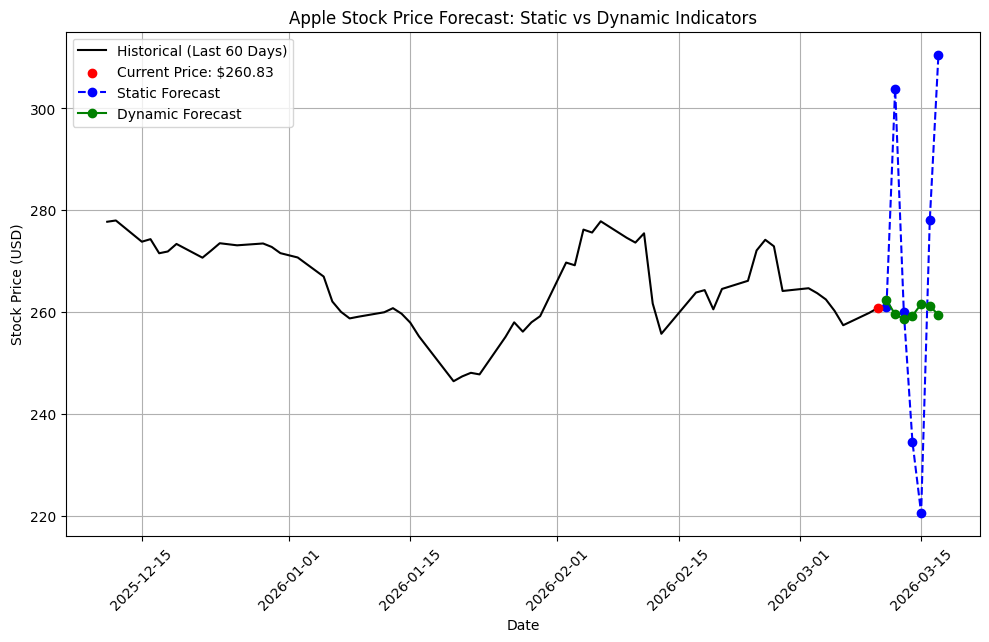

In [4]:
# Step: Plot static vs dynamic forecast comparison

import matplotlib.dates as mdates

# Assume you already have:
# - df (with historical prices)
# - current_price (latest close)
# - current_date (latest date)
# - future_preds (static forecast list)
# - future_preds_dynamic (dynamic forecast list)

# Create future dates for the next 7 days
future_dates = pd.date_range(start=current_date + pd.Timedelta(days=1), periods=7)

plt.figure(figsize=(10, 6))

# Plot historical closing prices (last 60 days for context)
plt.plot(df.index[-60:], df['Close'].iloc[-60:], label='Historical (Last 60 Days)', color='black')

# Plot current price
plt.scatter(current_date, current_price.item(), color='red',
            label=f'Current Price: ${current_price.item():.2f}', zorder=5)

# Plot static forecast
plt.plot(future_dates, future_preds, marker='o', linestyle='--', color='blue', label='Static Forecast')

# Plot dynamic forecast
plt.plot(future_dates, future_preds_dynamic, marker='o', linestyle='-', color='green', label='Dynamic Forecast')

# Formatting
plt.title('Apple Stock Price Forecast: Static vs Dynamic Indicators')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Improve date formatting on x-axis
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.savefig("apple_forecast_static_vs_dynamic.png", dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Step: Compare metrics for static vs dynamic forecasts

# Static forecast metrics (using test set predictions)
mse_static = mean_squared_error(y_test, y_pred)
rmse_static = np.sqrt(mse_static)
mae_static = mean_absolute_error(y_test, y_pred)
r2_static = r2_score(y_test, y_pred)

# Dynamic forecast metrics (using last 7 actual closes vs dynamic forecast)
actual_future = df['Close'].iloc[-7:].values  # last 7 actual closes
mse_dynamic = mean_squared_error(actual_future, future_preds_dynamic)
rmse_dynamic = np.sqrt(mse_dynamic)
mae_dynamic = mean_absolute_error(actual_future, future_preds_dynamic)
r2_dynamic = r2_score(actual_future, future_preds_dynamic)

# Build DataFrame for comparison
comparison_df = pd.DataFrame({
    "RMSE": [round(rmse_static,2), round(rmse_dynamic,2)],
    "MAE": [round(mae_static,2), round(mae_dynamic,2)],
    "R²": [round(r2_static,4), round(r2_dynamic,4)]
}, index=["Static","Dynamic"])

print("\n## Forecast Comparison (Static vs Dynamic)\n")
print(tabulate(comparison_df, headers='keys', tablefmt='github'))



## Forecast Comparison (Static vs Dynamic)

|         |   RMSE |   MAE |      R² |
|---------|--------|-------|---------|
| Static  |   2.05 |  1.45 |  0.9955 |
| Dynamic |   2.91 |  2.6  | -0.5921 |
